In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("imbalanced_dataset.csv")
df.head()

,x1,x2,label
0,0.304717,-1.039984,0
1,0.750451,0.940565,0
2,-1.951035,-1.302180,0
3,0.127840,-0.316243,0
4,-0.016801,-0.853044,0


In [ ]:
## imbalanced dataset 

df['label'].value_counts()

label
0    900
1    100
Name: count, dtype: int64

# Technique1->Up sampling

In [7]:
df_majority=df[df['label']==0]
df_minority=df[df['label']==1]

In [10]:


from sklearn.utils import resample
df_minority_updated=resample(df_minority,replace=True,n_samples=len(df_majority),random_state=42)
df_minority_updated.shape


(900, 3)

In [13]:
df_upsampled=pd.concat([df_minority_updated,df_majority])
df_upsampled['label'].value_counts()

label
1    900
0    900
Name: count, dtype: int64

# Technique2->DownSampling

In [ ]:
df_majority=df[df['label']==0]
df_minority=df[df['label']==1]

In [17]:


from sklearn.utils import resample
df_majority_updated=resample(df_majority,replace=False,n_samples=len(df_minority),random_state=42)
df_majority_updated.shape


(100, 3)

In [18]:
df_downsampled=pd.concat([df_majority_updated,df_minority])
df_downsampled['label'].value_counts()

label
0    100
1    100
Name: count, dtype: int64

# SMOTE(SYNTHETIC MINORITY OVERSAMPLING TECHNIQUE)

In [ ]:
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,weights=[0.90],random_state=23,n_redundant=0)



array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [23]:
import pandas as pd 

df1=pd.DataFrame(x,columns=["feature1","feature2"])
df2=pd.DataFrame(y,columns=["target"])

In [36]:
final_df=pd.concat([df1,df2],axis=1)

In [37]:
final_df.head()

,feature1,feature2,target
0,-0.592870,1.224422,0
1,-1.241040,0.643944,0
2,-1.120830,-0.393508,1
3,-2.169750,-0.130374,0
4,-2.020505,1.506183,1


In [38]:
final_df["target"].value_counts()

target
0    899
1    101
Name: count, dtype: int64

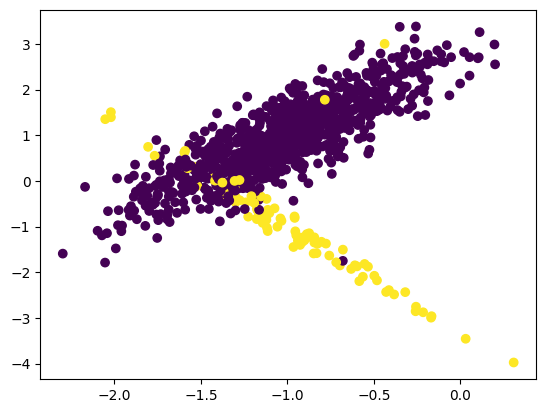

In [39]:
import matplotlib.pyplot as plt
plt.scatter(final_df["feature1"],final_df["feature2"],c=final_df["target"])
plt.show()

In [40]:
!pip install imblearn


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from imblearn.over_sampling import SMOTE

In [41]:
oversample=SMOTE()
X,Y=oversample.fit_resample(final_df[["feature1","feature2"]],final_df["target"])

In [47]:
X.shape
X

,feature1,feature2
0,-0.592870,1.224422
1,-1.241040,0.643944
2,-1.120830,-0.393508
3,-2.169750,-0.130374
4,-2.020505,1.506183
...,...,...
1793,-1.013482,-1.045465
1794,-0.923001,-1.220736
1795,-1.335458,0.002354
1796,-1.875102,1.144890


In [43]:
Y.shape

(1798,)

In [48]:
df1=pd.DataFrame(X,columns=["feature1","feature2"])
df2=pd.DataFrame(Y,columns=["target"])
final_df=pd.concat([df1,df2],axis=1)
final_df["target"].value_counts()
final_df.head()

,feature1,feature2,target
0,-0.592870,1.224422,0
1,-1.241040,0.643944,0
2,-1.120830,-0.393508,1
3,-2.169750,-0.130374,0
4,-2.020505,1.506183,1


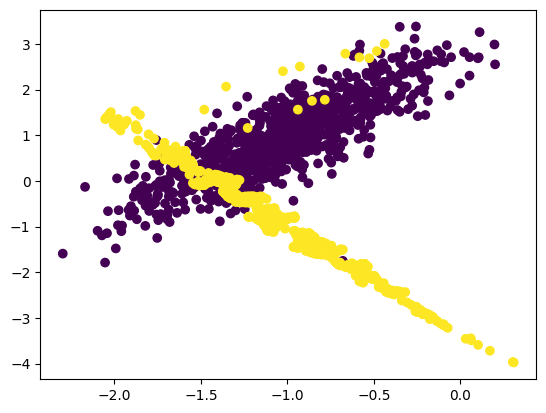

In [50]:
plt.scatter(final_df["feature1"],final_df["feature2"],c=final_df["target"])

(100, 3)